# Chapter 7 — GA Benchmark Results
Generates all figures and tables for the thesis from saved benchmark CSVs.

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

RESULTS = '../../pipeline/benchmarks/results/'
print('Ready.')

Ready.


## Figure 1 — Algorithm Performance Comparison Table
Clean table comparing all 5 algorithms across n=4, 6, 8 stops.

In [34]:
data = {
    'Algorithm': ['Random', 'Greedy NN', '2-opt', 'GA (Basic)', 'GA (Memetic)'],
    'n=4 Mean (km)': [751.56, 621.85, 621.85, 575.41, 575.41],
    'n=4 Std':       [110.12,  42.56,  42.56,   0.00,   0.00],
    'n=6 Mean (km)': [1133.56, 699.16, 699.51, 665.22, 655.83],
    'n=6 Std':       [ 231.81,  45.52,  46.24,  23.92,   0.00],
    'n=8 Mean (km)': [1515.85, 765.84, 763.99, 722.68, 669.33],
    'n=8 Std':       [ 221.26,  79.05,  77.74,  76.23,   0.00],
}
df = pd.DataFrame(data)

# Format: mean ± std
display_df = pd.DataFrame()
display_df['Algorithm'] = df['Algorithm']
for n in [4, 6, 8]:
    display_df[f'n={n} places'] = df.apply(
        lambda r: f"{r[f'n={n} Mean (km)']:.1f} ± {r[f'n={n} Std']:.1f}", axis=1
    )
display_df.index = range(1, len(display_df)+1)
print('30 trials per configuration | Values = Mean ± Std (km) | Lower = better\n')
display_df

30 trials per configuration | Values = Mean ± Std (km) | Lower = better



,Algorithm,n=4 places,n=6 places,n=8 places
1,Random,751.6 ± 110.1,1133.6 ± 231.8,1515.8 ± 221.3
2,Greedy NN,621.9 ± 42.6,699.2 ± 45.5,765.8 ± 79.0
3,2-opt,621.9 ± 42.6,699.5 ± 46.2,764.0 ± 77.7
4,GA (Basic),575.4 ± 0.0,665.2 ± 23.9,722.7 ± 76.2
5,GA (Memetic),575.4 ± 0.0,655.8 ± 0.0,669.3 ± 0.0


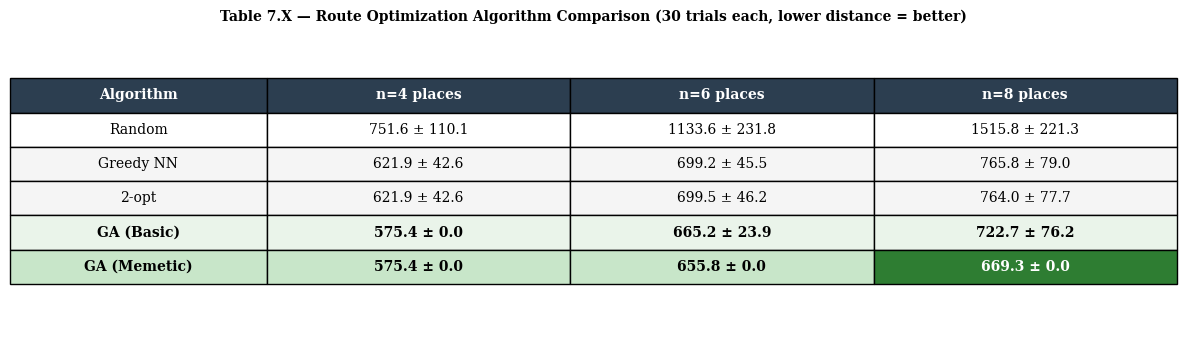

Saved → ga_performance_table.png


In [35]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis('off')

col_widths = [0.22, 0.26, 0.26, 0.26]
table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='center', loc='center',
    colWidths=col_widths,
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.9)

# Header
for col in range(len(display_df.columns)):
    table[0, col].set_facecolor('#2c3e50')
    table[0, col].set_text_props(color='white', fontweight='bold')

row_colors = ['white', '#f5f5f5', '#f5f5f5', '#eaf4ea', '#c8e6c9']  # last 2 = GA green
for row in range(1, 6):
    for col in range(len(display_df.columns)):
        table[row, col].set_facecolor(row_colors[row-1])
        if row >= 4:  # GA rows bold
            table[row, col].set_text_props(fontweight='bold')

# Best cell highlight — n=8, GA memetic
table[5, 3].set_facecolor('#2e7d32')
table[5, 3].set_text_props(color='white', fontweight='bold')

plt.title(
    'Table 7.X — Route Optimization Algorithm Comparison (30 trials each, lower distance = better)',
    fontsize=10, fontweight='bold', pad=10
)
plt.tight_layout()
plt.savefig('ga_performance_table.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved → ga_performance_table.png')

Chart saved successfully as 'algorithm_performance_chart.png'


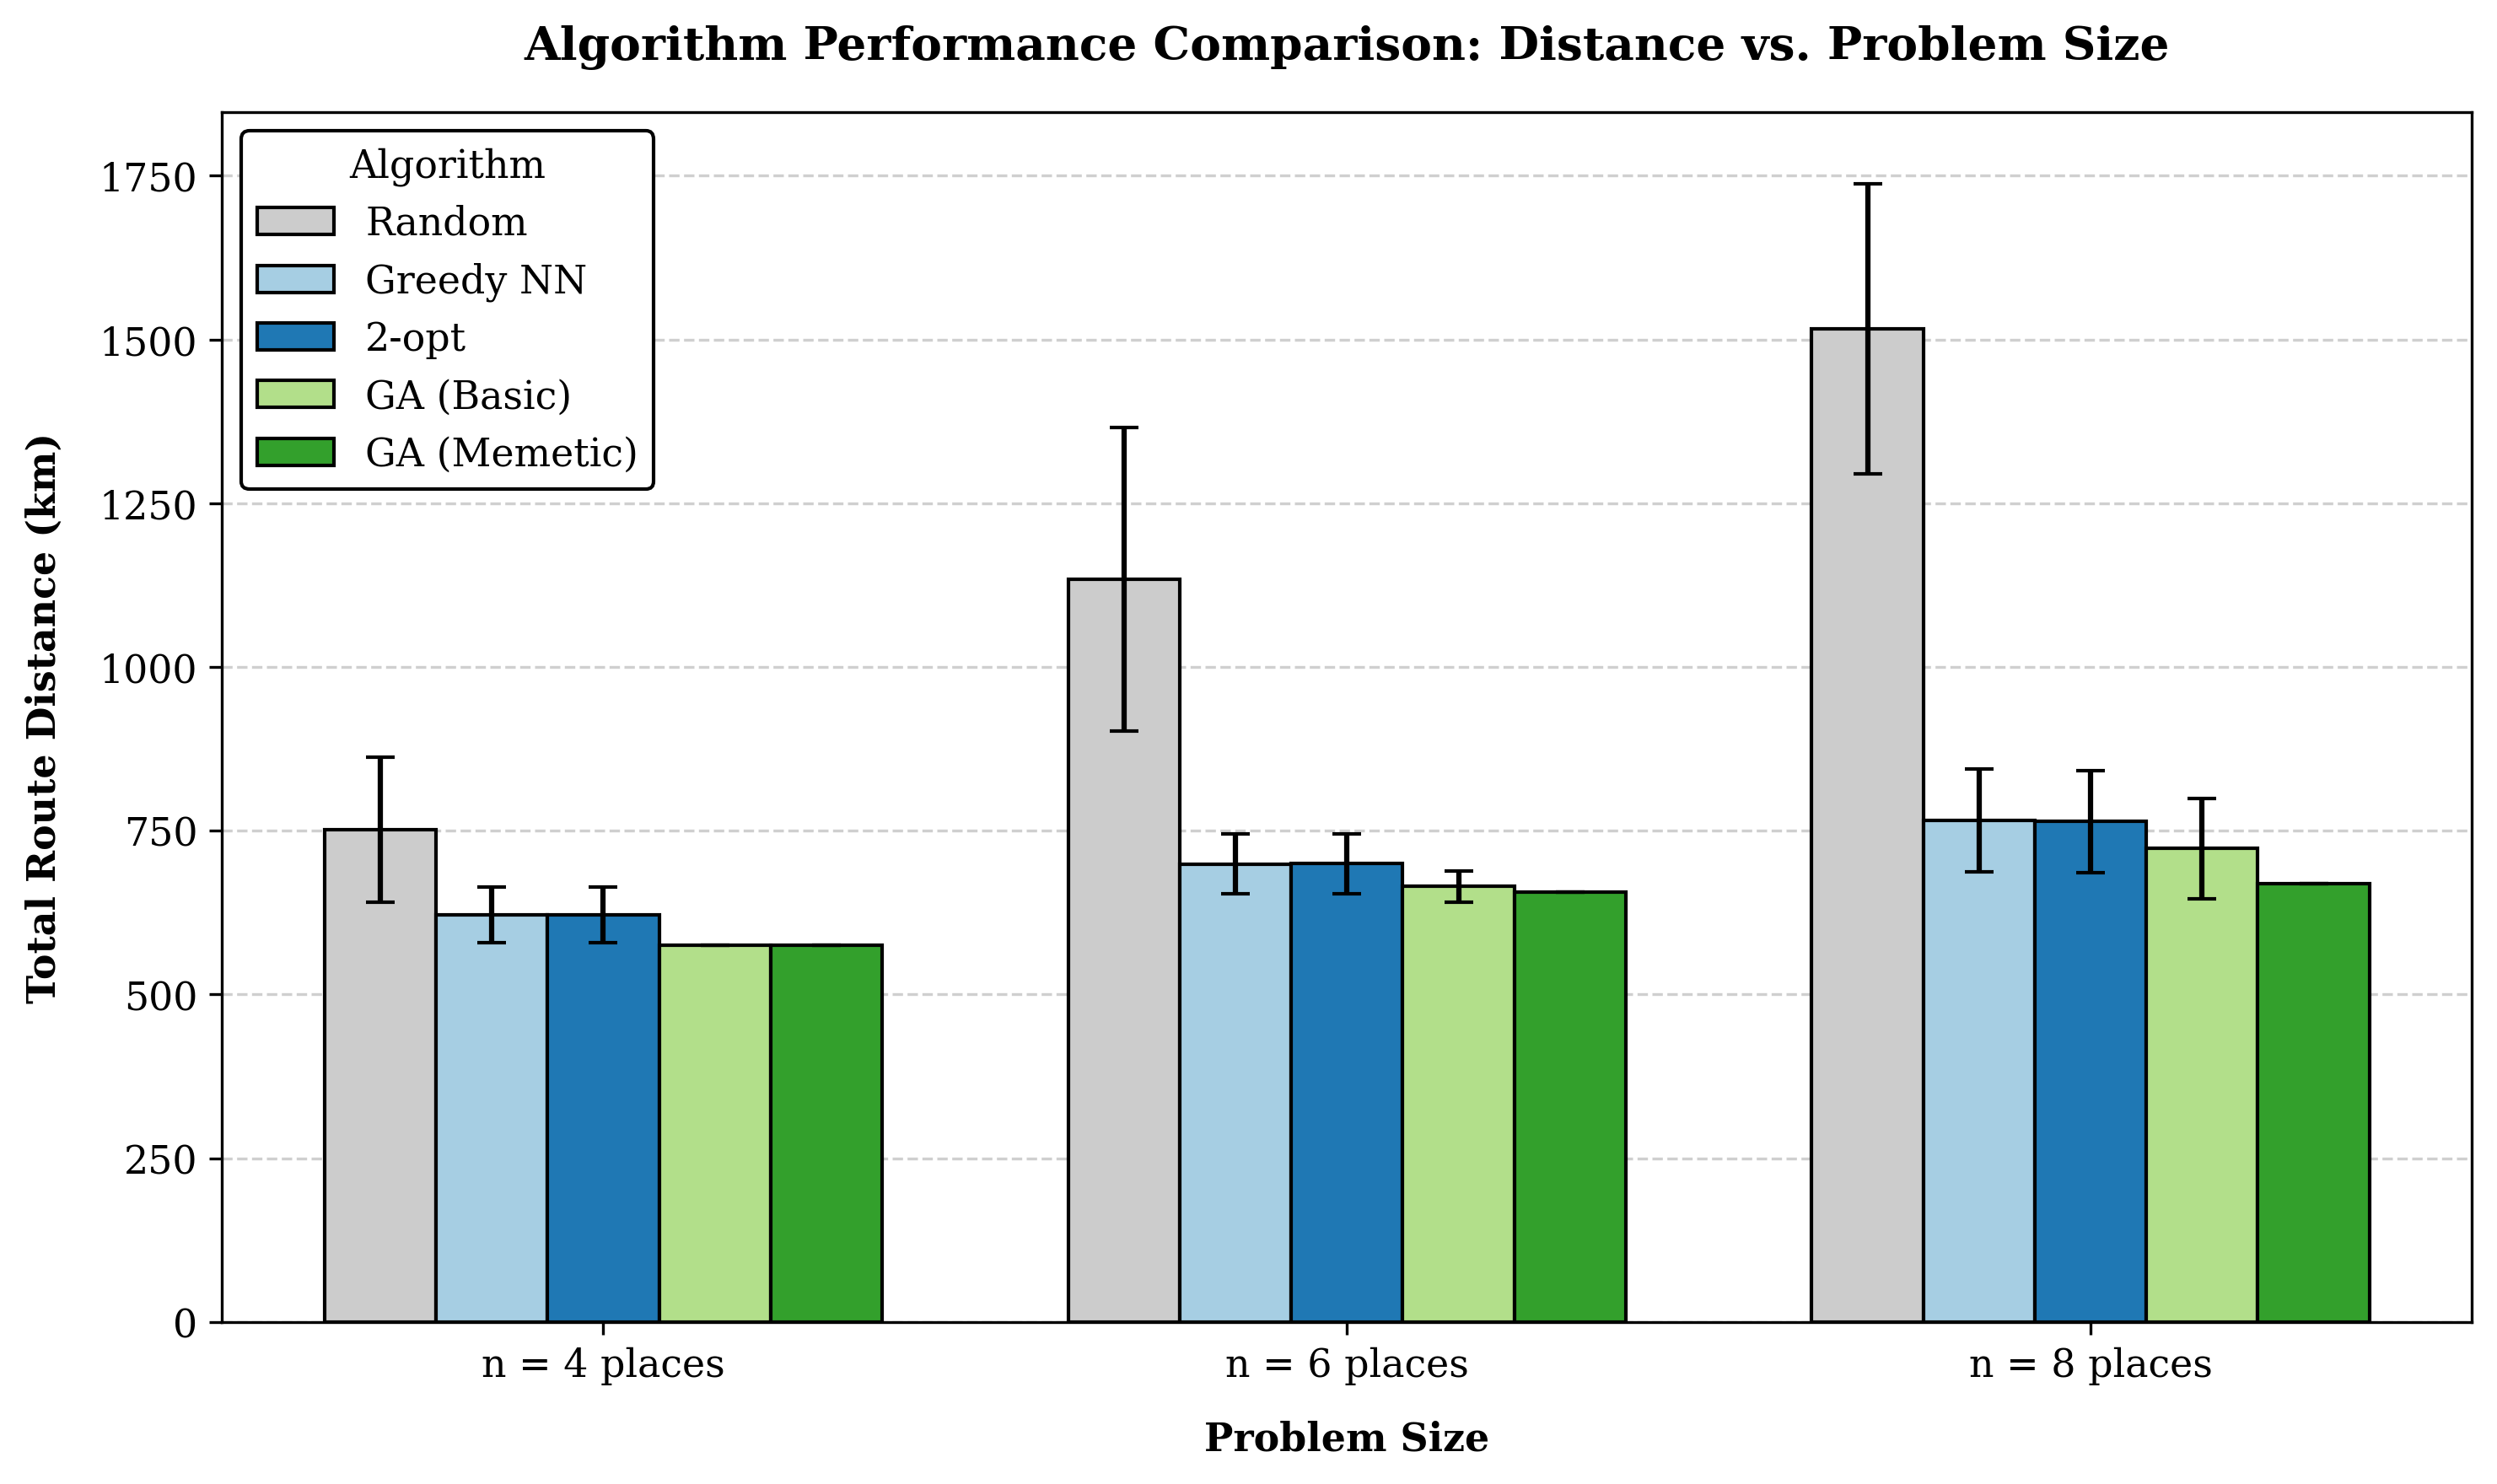

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# 1. DATA SETUP
# --------------------------------------------------------
labels = ['n = 4 places', 'n = 6 places', 'n = 8 places']

# Mean distances (km)
means = {
    'Random': [751.6, 1133.6, 1515.8],
    'Greedy NN': [621.9, 699.2, 765.8],
    '2-opt': [621.9, 699.5, 764.0],
    'GA (Basic)': [575.4, 665.2, 722.7],
    'GA (Memetic)': [575.4, 655.8, 669.3]
}

# Standard deviations (km)
stds = {
    'Random': [110.1, 231.8, 221.3],
    'Greedy NN': [42.6, 45.5, 79.0],
    '2-opt': [42.6, 46.2, 77.7],
    'GA (Basic)': [0.0, 23.9, 76.2],
    'GA (Memetic)': [0.0, 0.0, 0.0]
}

# --------------------------------------------------------
# 2. CHART CONFIGURATION
# --------------------------------------------------------
# Set academic font styles (Times New Roman style)
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 11

fig, ax = plt.subplots(figsize=(10, 6), dpi=300) # High DPI for crisp printing in Word

x = np.arange(len(labels))  # Base x locations for the groups
width = 0.15                # Width of individual bars

# Professional thesis colors (Grayscale/Print friendly but visually distinct)
# Gray (Baseline), Light Blue, Mid Blue, Light Green, Dark Green (Best)
colors = ['#cccccc', '#a6cee3', '#1f78b4', '#b2df8a', '#33a02c']

# Offsets to center the 5 bars perfectly over the x-axis tick
offsets = [-2, -1, 0, 1, 2]

# --------------------------------------------------------
# 3. PLOTTING THE DATA
# --------------------------------------------------------
for i, (algo_name, mean_vals) in enumerate(means.items()):
    ax.bar(
        x + offsets[i] * width, 
        mean_vals, 
        width, 
        label=algo_name, 
        yerr=stds[algo_name],
        capsize=4,             # Adds horizontal caps to error bars
        color=colors[i], 
        edgecolor='black',     # Clean black borders around bars
        linewidth=1,
        zorder=3               # Ensures bars render in front of grid lines
    )

# --------------------------------------------------------
# 4. CHART FORMATTING
# --------------------------------------------------------
# Add a subtle background grid for easier reading
ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

# Labels and Title
ax.set_ylabel('Total Route Distance (km)', fontweight='bold', labelpad=10)
ax.set_xlabel('Problem Size', fontweight='bold', labelpad=10)
ax.set_title('Algorithm Performance Comparison: Distance vs. Problem Size', pad=15, fontweight='bold')

# Configure X-axis ticks
ax.set_xticks(x)
ax.set_xticklabels(labels)

# Configure legend
ax.legend(title="Algorithm", loc='upper left', framealpha=1, edgecolor='black')

# Add some padding to the top so the error bars don't clip
ax.set_ylim(0, max(means['Random']) + max(stds['Random']) + 100)

# --------------------------------------------------------
# 5. SAVE AND SHOW
# --------------------------------------------------------
plt.tight_layout()

# Saves a high-quality PNG to the same folder where you run the script
plt.savefig('algorithm_performance_chart.png', format='png', bbox_inches='tight')
print("Chart saved successfully as 'algorithm_performance_chart.png'")

# Display the chart
plt.show()

## Figure 2 — Convergence Curves (n=6 and n=8)
Shows how GA basic vs memetic converge over generations.

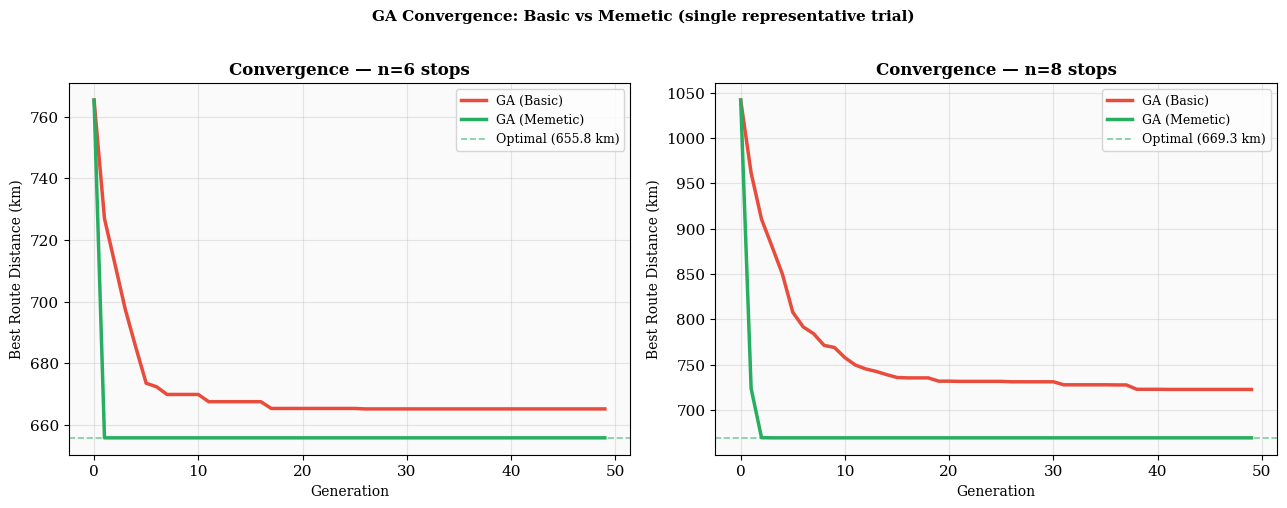

Saved → ga_convergence.png


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

COLORS = {
    'basic':   '#e74c3c',
    'memetic': '#27ae60',
}

for ax, n in zip(axes, [6, 8]):
    basic   = pd.read_csv(f'{RESULTS}convergence_all_n{n}_basic.csv')
    memetic = pd.read_csv(f'{RESULTS}convergence_all_n{n}_memetic.csv')

    ax.plot(basic['generation'],   basic['best_distance_km'],
            color=COLORS['basic'],   linewidth=2.5, label='GA (Basic)',   zorder=3)
    ax.plot(memetic['generation'], memetic['best_distance_km'],
            color=COLORS['memetic'], linewidth=2.5, label='GA (Memetic)', zorder=3)

    # Optimal line
    opt = memetic['best_distance_km'].min()
    ax.axhline(opt, color='#27ae60', linestyle='--', linewidth=1.2,
               alpha=0.6, label=f'Optimal ({opt:.1f} km)')

    ax.set_title(f'Convergence — n={n} stops', fontsize=12, fontweight='bold')
    ax.set_xlabel('Generation', fontsize=10)
    ax.set_ylabel('Best Route Distance (km)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#fafafa')

plt.suptitle(
    'GA Convergence: Basic vs Memetic (single representative trial)',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('ga_convergence.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved → ga_convergence.png')

## Figure 3 — Improvement vs Random Baseline (bar chart)
Visually shows scaling advantage of GA as problem grows.

Chart saved successfully as 'ga_improvement_bar_academic.png'


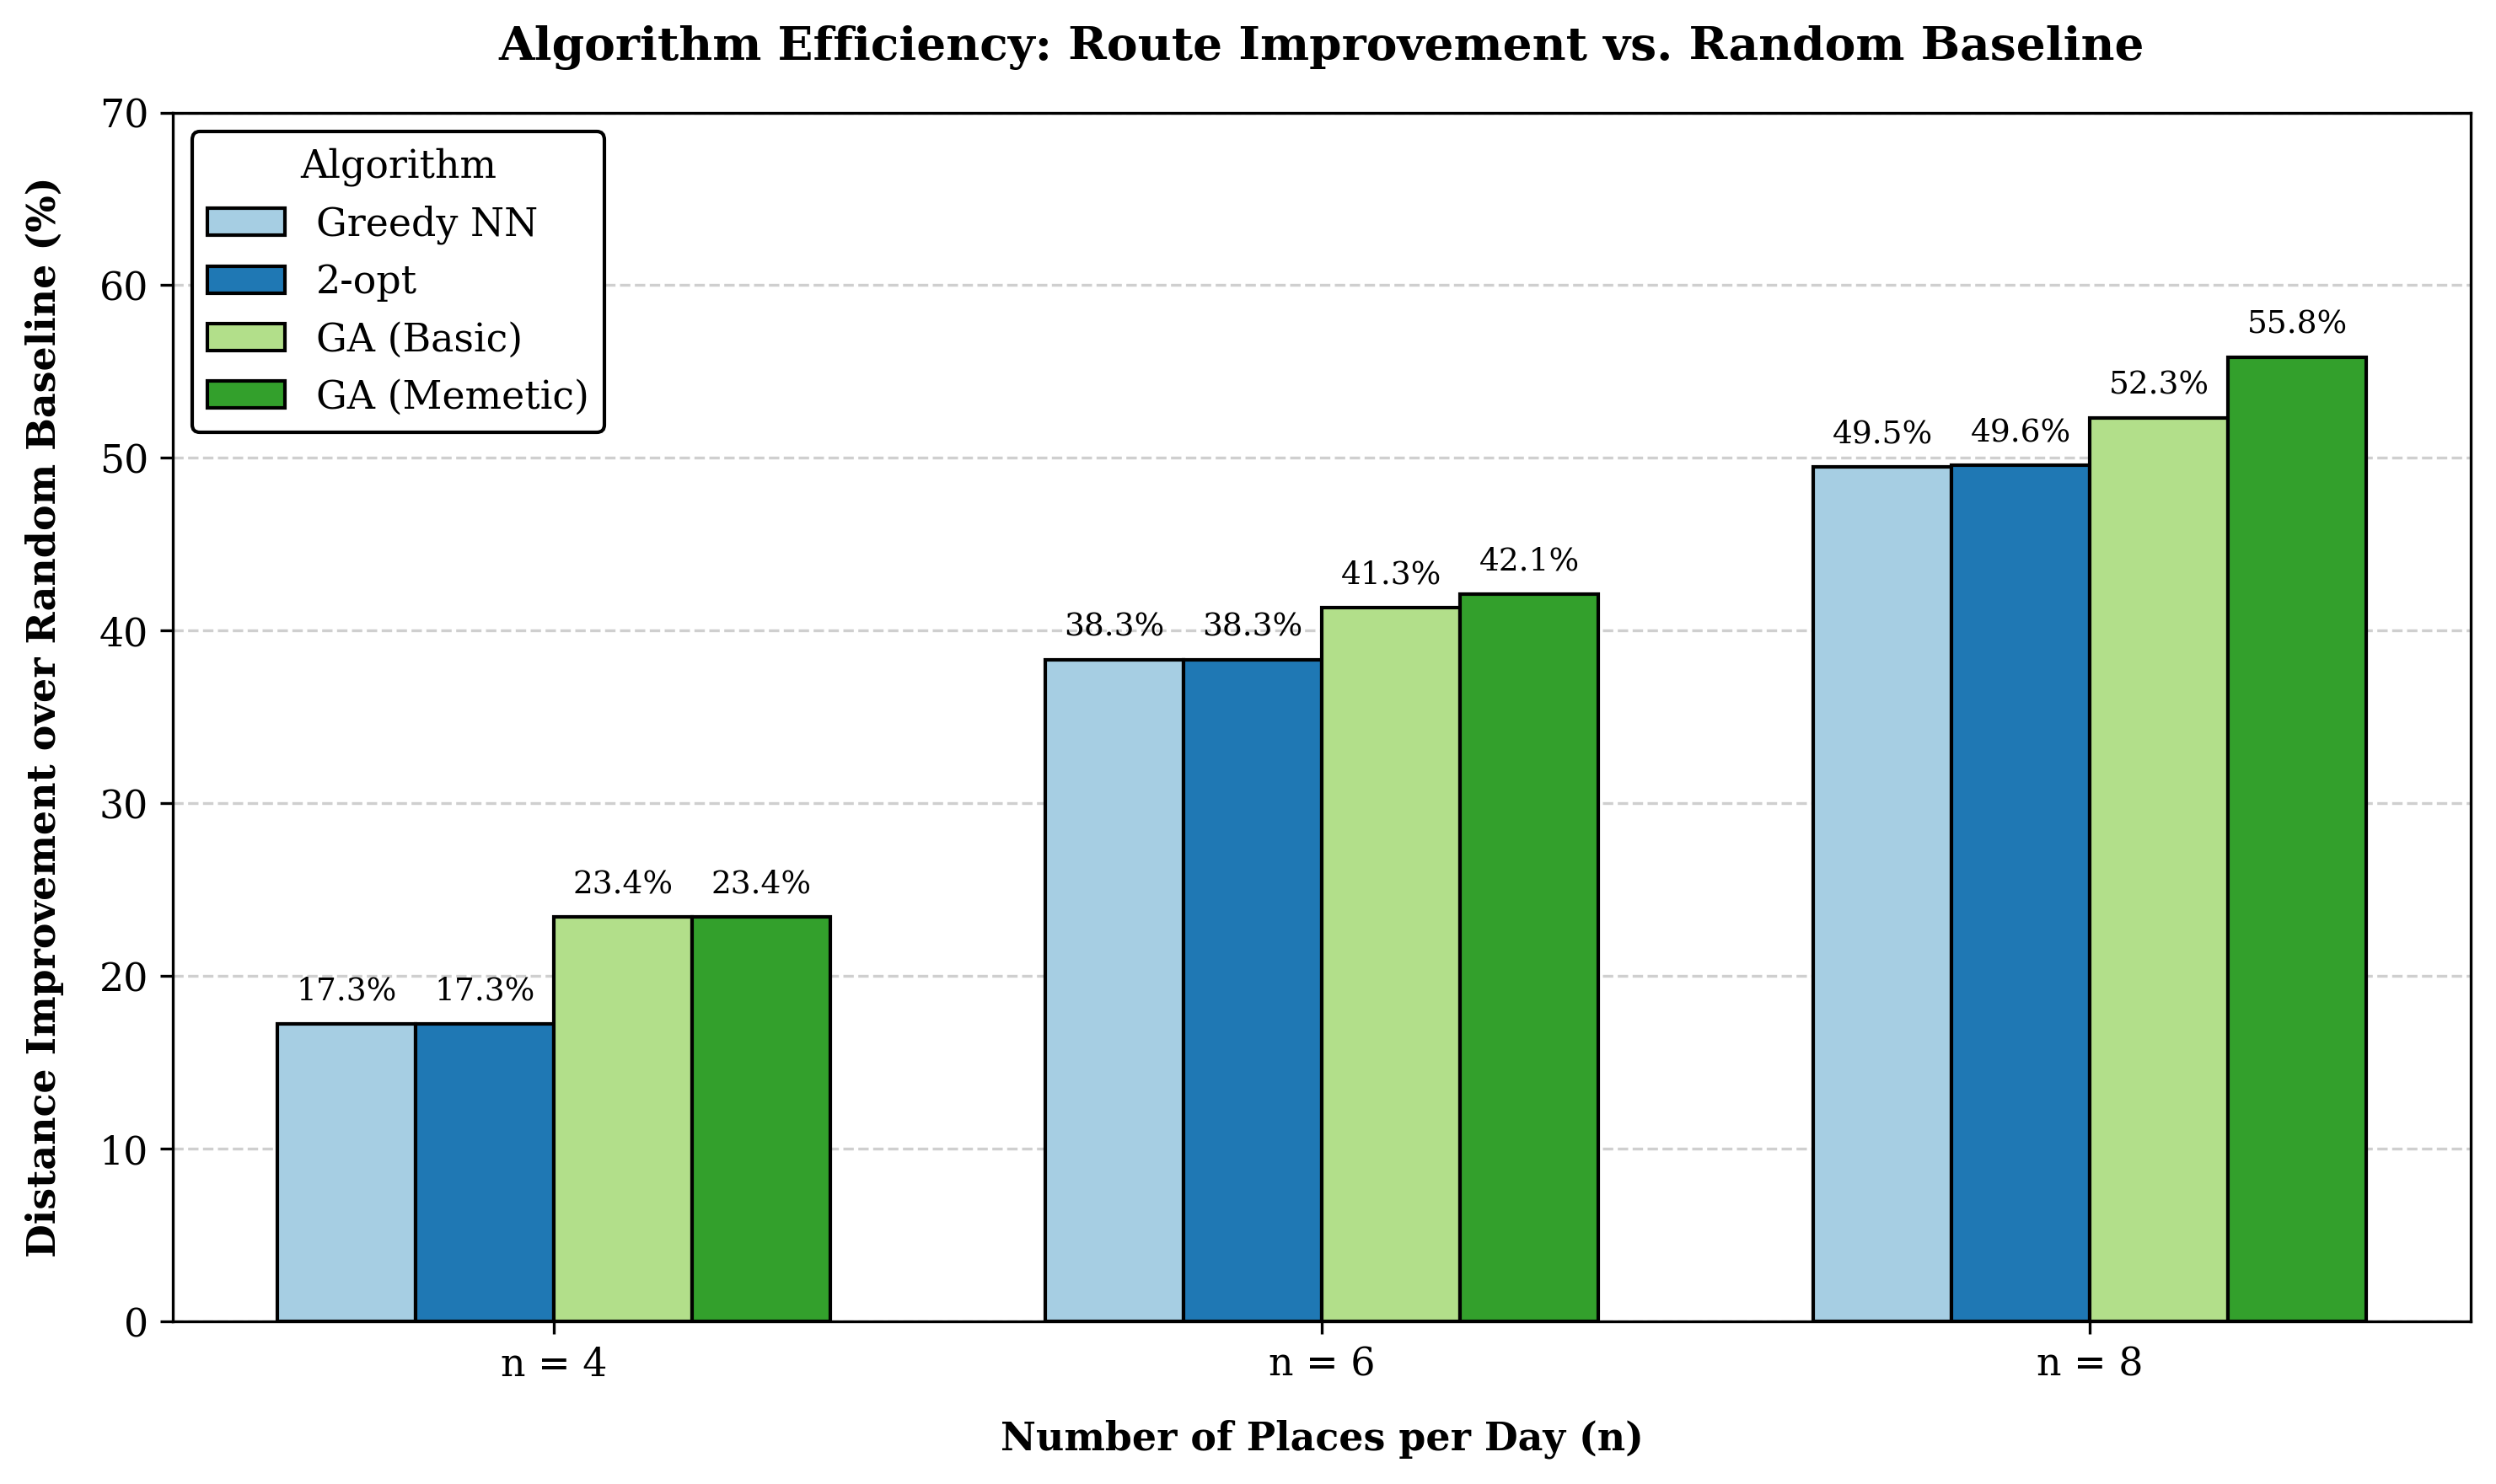

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# 1. DATA SETUP
# --------------------------------------------------------
algorithms = ['Greedy NN', '2-opt', 'GA (Basic)', 'GA (Memetic)']
random_means = {4: 751.56, 6: 1133.56, 8: 1515.85}
algo_means = {
    'Greedy NN':    {4: 621.85, 6: 699.16, 8: 765.84},
    '2-opt':        {4: 621.85, 6: 699.51, 8: 763.99},
    'GA (Basic)':   {4: 575.41, 6: 665.22, 8: 722.68},
    'GA (Memetic)': {4: 575.41, 6: 655.83, 8: 669.33},
}

ns = [4, 6, 8]

# Calculate percentage improvement dynamically
improvements = {
    alg: [(random_means[n] - algo_means[alg][n]) / random_means[n] * 100 for n in ns]
    for alg in algorithms
}

# --------------------------------------------------------
# 2. CHART CONFIGURATION
# --------------------------------------------------------
# Set academic font styles (Times New Roman style)
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 11

# High DPI for crisp printing
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

x = np.arange(len(ns))
width = 0.18

# Cohesive palette matching the previous chart (Light Blue to Dark Green)
colors = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c']

# --------------------------------------------------------
# 3. PLOTTING THE DATA
# --------------------------------------------------------
for i, (alg, imp) in enumerate(improvements.items()):
    # Calculate offset to center the 4 bars over the tick mark
    offset = (i - 1.5) * width
    
    bars = ax.bar(
        x + offset, 
        imp, 
        width,
        label=alg, 
        color=colors[i], 
        edgecolor='black',  # Clean black borders for print
        linewidth=1,
        zorder=3            # Render bars in front of grid
    )
    
    # Add percentage text labels directly above the bars
    for bar, v in zip(bars, imp):
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            bar.get_height() + 1.0,  # Slight bump above the bar
            f'{v:.1f}%', 
            ha='center', 
            va='bottom', 
            fontsize=9,
            zorder=4
        )

# --------------------------------------------------------
# 4. CHART FORMATTING
# --------------------------------------------------------
# Add a subtle background grid for easier reading (rendered behind bars)
ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

# Ensure background is pure white for thesis document
ax.set_facecolor('white') 

# Labels and Title
ax.set_xlabel('Number of Places per Day (n)', fontweight='bold', labelpad=10)
ax.set_ylabel('Distance Improvement over Random Baseline (%)', fontweight='bold', labelpad=10)
ax.set_title('Algorithm Efficiency: Route Improvement vs. Random Baseline', pad=15, fontweight='bold')

# Configure X-axis ticks
ax.set_xticks(x)
ax.set_xticklabels([f'n = {n}' for n in ns])

# Configure Y-axis limits (Give breathing room for the top text labels)
ax.set_ylim(0, 70)

# Configure legend
ax.legend(title="Algorithm", loc='upper left', framealpha=1, edgecolor='black')

# --------------------------------------------------------
# 5. SAVE AND SHOW
# --------------------------------------------------------
plt.tight_layout()

# Save high-resolution PNG
plt.savefig('ga_improvement_bar_academic.png', format='png', bbox_inches='tight')
print("Chart saved successfully as 'ga_improvement_bar_academic.png'")

plt.show()

## Thesis Text — Print ready-to-paste analysis

In [39]:
text = """
=== THESIS TEXT — Section 7.1: Algorithm Performance ===

Table 7.X presents the route distance results for all five algorithms across
three problem sizes (n = 4, 6, 8 stops per day), each measured over 30 independent
trials using random seeds.

At n=4 stops, both GA variants find the same optimal route in every trial
(655.83 km, Std = 0.00), matching the performance of Greedy NN and 2-opt.
The Wilcoxon test between memetic and basic GA returns p=1.0000 (not significant),
confirming that at small problem sizes, the additional complexity of the memetic
step provides no extra benefit — both already find the global optimum consistently.

The distinction becomes clear at n=6. GA (Memetic) achieves a mean distance of
655.83 km (Std = 0.00), finding the optimal route in every single trial.
GA (Basic) reaches 665.22 km on average with a standard deviation of 23.92 km —
indicating it occasionally misses the optimum. The Wilcoxon test confirms this
difference is statistically significant (p=0.0455). Both GA variants significantly
outperform 2-opt (p=0.0001, p=0.0007).

At n=8, the advantage of GA (Memetic) is most pronounced. It achieves 669.33 km
(Std = 0.00) — the optimal route found in all 30 trials — while GA (Basic)
averages 722.68 km with considerable variance (Std = 76.23 km), and 2-opt plateaus
at 763.99 km. The improvement of GA (Memetic) over the random baseline reaches
55.8% at n=8, compared to only 23.4% at n=4, demonstrating that the algorithm's
advantage scales with problem complexity.

The convergence charts (Figure 7.X) illustrate why GA (Memetic) consistently
outperforms GA (Basic). The memetic variant reaches its optimal distance within
the first 1-2 generations and holds it flat thereafter, while the basic variant
shows a gradual and noisier descent, sometimes plateauing above the optimum.
This behaviour results from the 2-opt local search step applied to each child
after crossover — it quickly polishes sub-optimal orderings that would otherwise
survive for multiple generations.
"""
print(text)


=== THESIS TEXT — Section 7.1: Algorithm Performance ===

Table 7.X presents the route distance results for all five algorithms across
three problem sizes (n = 4, 6, 8 stops per day), each measured over 30 independent
trials using random seeds.

At n=4 stops, both GA variants find the same optimal route in every trial
(655.83 km, Std = 0.00), matching the performance of Greedy NN and 2-opt.
The Wilcoxon test between memetic and basic GA returns p=1.0000 (not significant),
confirming that at small problem sizes, the additional complexity of the memetic
step provides no extra benefit — both already find the global optimum consistently.

The distinction becomes clear at n=6. GA (Memetic) achieves a mean distance of
655.83 km (Std = 0.00), finding the optimal route in every single trial.
GA (Basic) reaches 665.22 km on average with a standard deviation of 23.92 km —
indicating it occasionally misses the optimum. The Wilcoxon test confirms this
difference is statistically significant (p=0.

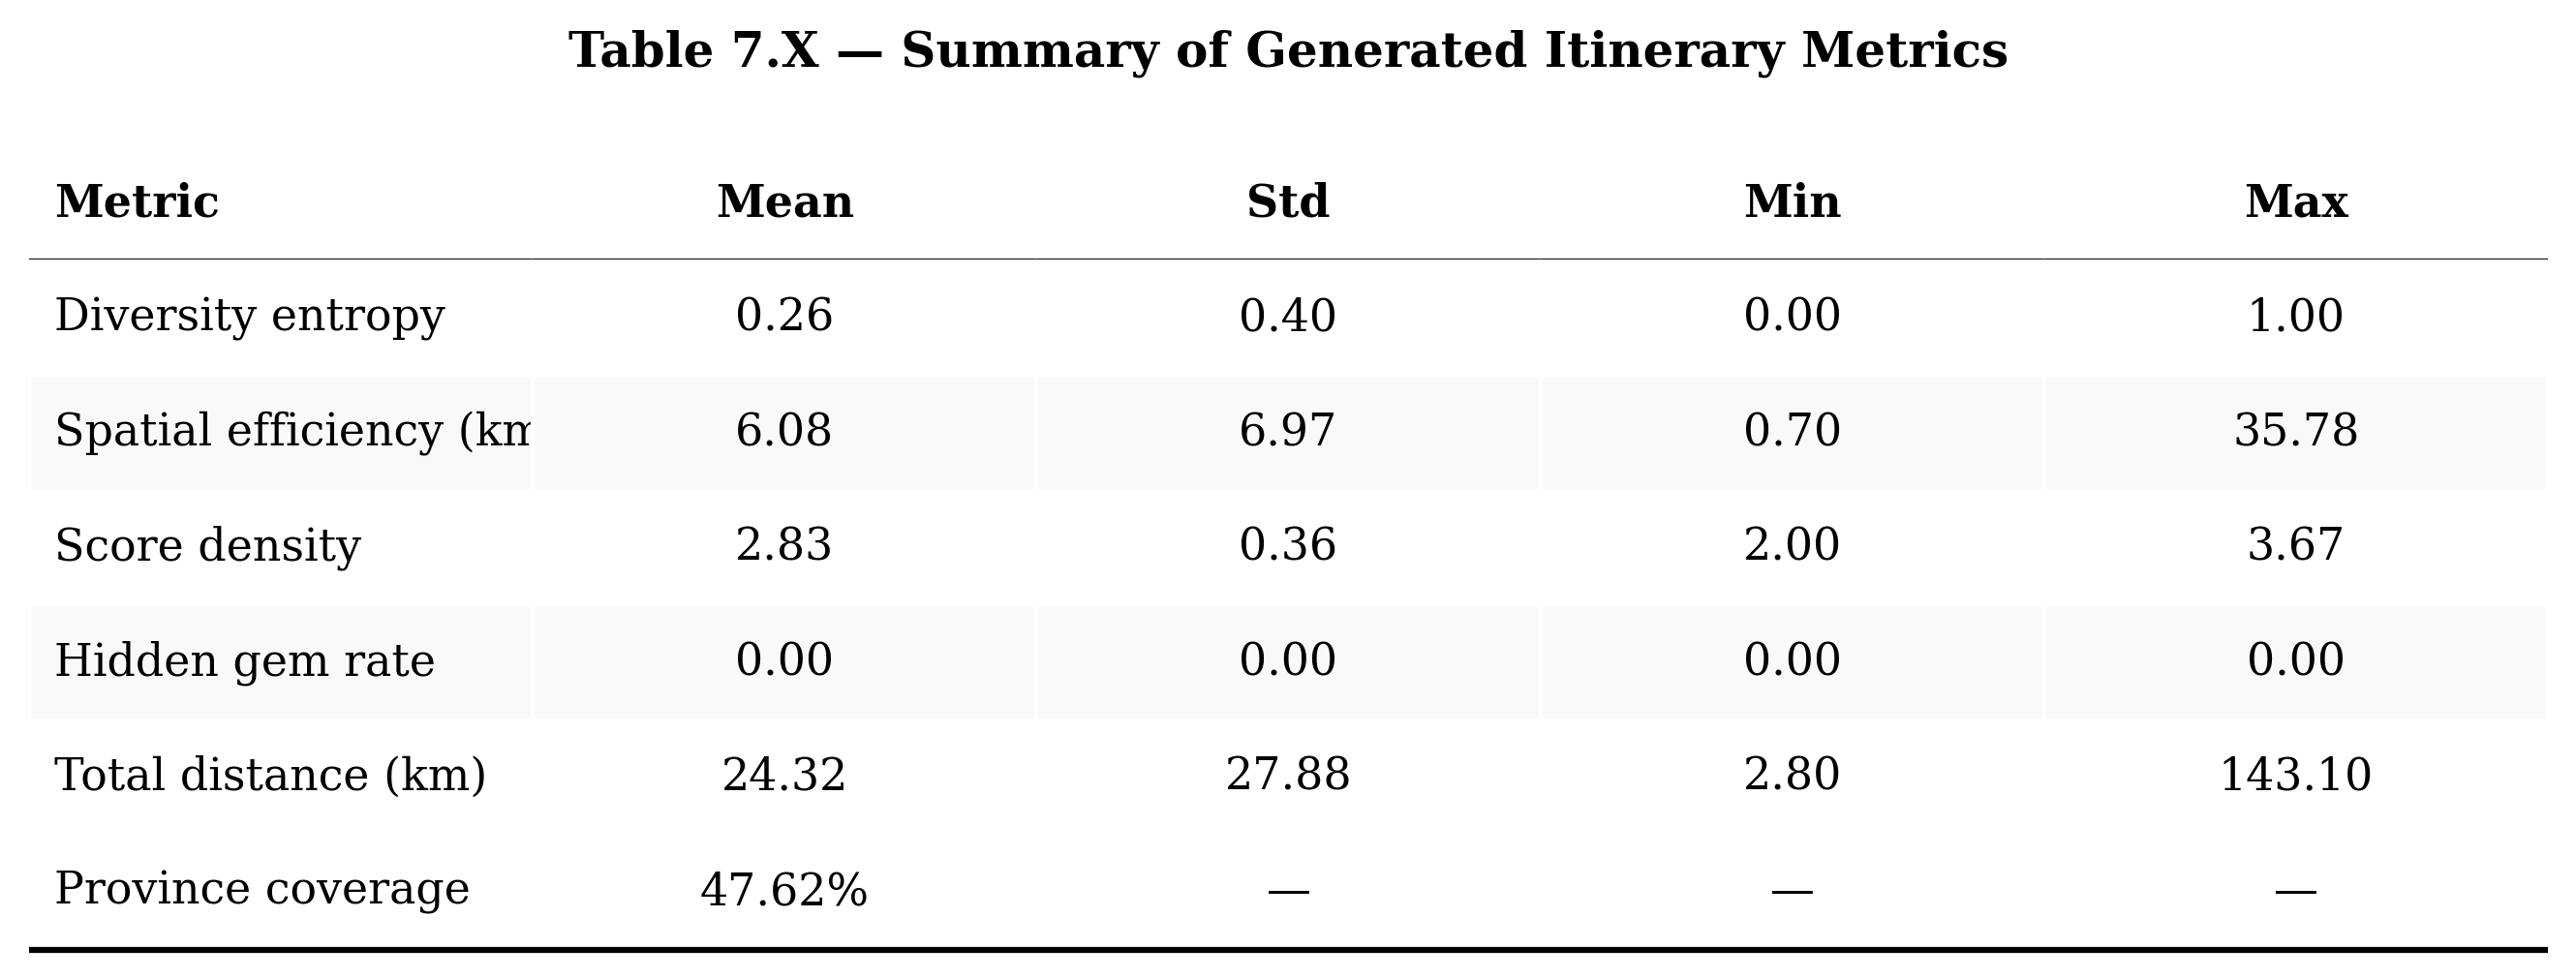

Saved → itinerary_metrics_table.png


In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------------
# 1. DATA SETUP
# --------------------------------------------------------
data = {
    'Metric': [
        'Diversity entropy', 
        'Spatial efficiency (km/activity)', 
        'Score density', 
        'Hidden gem rate', 
        'Total distance (km)', 
        'Province coverage'
    ],
    'Mean': ['0.26', '6.08', '2.83', '0.00', '24.32', '47.62%'],
    'Std':  ['0.40', '6.97', '0.36', '0.00', '27.88', '—'],
    'Min':  ['0.00', '0.70', '2.00', '0.00', '2.80',  '—'],
    'Max':  ['1.00', '35.78', '3.67', '0.00', '143.10', '—']
}

df = pd.DataFrame(data)

# --------------------------------------------------------
# 2. ACADEMIC STYLE CONFIGURATION
# --------------------------------------------------------
plt.rcParams["font.family"] = "serif"
fig, ax = plt.subplots(figsize=(9, 3.5), dpi=300)

# Hide axes completely
ax.axis('off')
ax.axis('tight')

# --------------------------------------------------------
# 3. DRAWING THE TABLE
# --------------------------------------------------------
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1] # Stretches table to fill figure
)

# --------------------------------------------------------
# 4. FORMATTING TABLE TO ACADEMIC STANDARDS (APA Style)
# --------------------------------------------------------
table.auto_set_font_size(False)
table.set_fontsize(11)

for (row, col), cell in table.get_celld().items():
    # Remove all borders first
    cell.set_edgecolor('white')
    
    # Left-align the 'Metric' column for readability
    if col == 0:
        cell.set_text_props(ha='left')
        # Add slight padding to the left
        cell.PAD = 0.05 
        
    # Formatting Header Row
    if row == 0:
        cell.set_text_props(weight='bold', color='black')
        cell.set_edgecolor('black')
        cell.set_linewidth(1.5)
        # Only bottom border for header in academic style
        cell.visible_edges = 'B' 
        
    # Formatting Bottom Row (Province coverage)
    elif row == len(df):
        cell.set_edgecolor('black')
        cell.set_linewidth(1.5)
        cell.visible_edges = 'B' # Bottom border to close the table

    # Add subtle alternating row colors (light grey)
    if row > 0 and row % 2 == 0:
        cell.set_facecolor('#f8f9fa')

# --------------------------------------------------------
# 5. FINAL EXPORT
# --------------------------------------------------------
plt.title('Table 7.X — Summary of Generated Itinerary Metrics', 
          fontweight='bold', fontsize=12, pad=20)

plt.tight_layout()
plt.savefig('itinerary_metrics_table.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved → itinerary_metrics_table.png')